# Feature extraction: ipTM + pTM combined score

In [1]:
import pandas as pd
import os
import json

## A) RNase 

### Negative group ipTM+pTM extraction (RNA dependent)

For each complex: ipTM + pTM per model extracted from ranking_debug.json

In [2]:
# Per-model ipTM+pTM scores to dataframe; negative

def read_json_file(file_path):
    with open(file_path, 'r') as file:
        data = json.load(file)
    return data


folder_path = "/mnt/storage/ana01/results/afm_11_RNase_13_no_MOV10_copy"
rows = []

for folder in os.listdir(folder_path):
    if folder == '.DS_Store':
        continue
    elif folder.endswith("_multimer"):
        ranking_file = os.path.join(f"{folder_path}/{folder}", "ranking_debug.json")
        if os.path.exists(ranking_file):
            json_data = read_json_file(ranking_file)
            model_scores = json_data['iptm+ptm']  
            
            # Add each model as a new row
            for model_name, score in model_scores.items():
                rows.append({'Target': folder, 'Model': model_name, 'ipTM+pTM': score})
        else:
            print(f"ranking_debug.json not found in {folder}")

# Create the DataFrame from the rows list
df = pd.DataFrame(rows)

### Positive group ipTM+pTM extraction (RNA independent)

In [3]:
# Add ipTM+pTM scores to dataframe; positive 

def read_json_file(file_path):
    with open(file_path, 'r') as file:
        data = json.load(file)
    return data

folder_path = "/mnt/storage/ana01/results/afm_10_RNase_22_copy"
rows = []

for folder in os.listdir(folder_path):
    if folder == '.DS_Store':
        continue
    elif folder.endswith("_multimer"):
        ranking_file = os.path.join(f"{folder_path}/{folder}", "ranking_debug.json")
        if os.path.exists(ranking_file):
            json_data = read_json_file(ranking_file)
            model_scores = json_data['iptm+ptm']  # Dictionary of model scores
            
            # Add each model as a new row
            for model_name, score in model_scores.items():
                rows.append({'Target': folder, 'Model': model_name, 'ipTM+pTM': score})
        else:
            print(f"ranking_debug.json not found in {folder}")

# Create the DataFrame from the rows list
df_pos = pd.DataFrame(rows)

### Statistical analysis and visualization of distributions

#### Per model


Add class labels and merge positive and negative dataframes (per model)

In [4]:
df_pos['class']='RNase-independent'
df['class']='RNase-dependent'

cols_to_keep = ['Target', 'ipTM+pTM', 'class']

df_combined = pd.concat(
    [df_pos[cols_to_keep], df[cols_to_keep]],
    ignore_index=True
)

Statistical t-test (one-sided)  (per model)

In [5]:
from scipy.stats import ttest_ind

group1 = df_combined[df_combined['class'] == 'RNase-independent']['ipTM+pTM']
group2 = df_combined[df_combined['class'] == 'RNase-dependent']['ipTM+pTM']

# Welch’s t-test, one-sided (pos > neg)
t_stat, p_val = ttest_ind(
    group1,
    group2,
    equal_var=False,
    alternative='greater'
)

p_val_str = f"{p_val:.2e}"
p_val_str

'2.29e-02'

#### Per complex 

Averaging over all models

In [6]:
df_average = (
    df_combined
    .groupby('Target', as_index=False)
    .agg({
        'ipTM+pTM': 'mean',
        'class': 'first'   
    })
)

df_average = df_average.sort_values(
    by='class', 
    ascending=False
)

df_average.head()

,Target,ipTM+pTM,class
17,PURA_ORF2_multimer,0.294497,RNase-independent
25,RPS27A_ORF2_multimer,0.384454,RNase-independent
28,TUBB4B_ORF2_multimer,0.276135,RNase-independent
29,TUBB_ORF2_multimer,0.285363,RNase-independent
30,UBA52_ORF2_multimer,0.379031,RNase-independent


Welch's t-test (one-sided)

In [7]:
from scipy.stats import ttest_ind

group1 = df_average[df_average['class'] == 'RNase-independent']['ipTM+pTM']
group2 = df_average[df_average['class'] == 'RNase-dependent']['ipTM+pTM']

# Welch’s t-test, one-sided (pos > neg)
t_stat, p_val = ttest_ind(
    group1,
    group2,
    equal_var=False,
    alternative='greater'
)

p_val_str = f"{p_val:.2e}"

Boxplot; ipTM + pTM per complex

/tmp/ipykernel_805357/3791444930.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


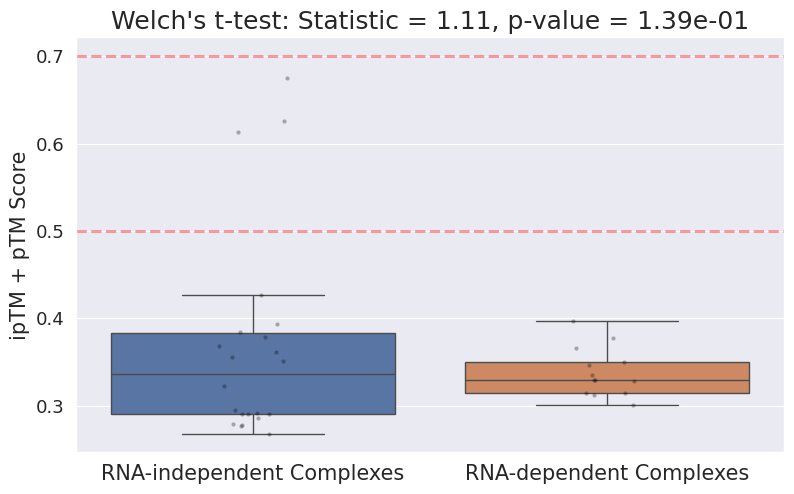

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.set_style("darkgrid")
sns.set_context("paper", font_scale=0.9)

sns.boxplot(
    data=df_average,
    x='class',
    y='ipTM+pTM',
    palette={
        'RNase-independent': sns.color_palette('deep')[0],  
        'RNase-dependent': sns.color_palette('deep')[1]     
    },
    showfliers=False
)

sns.stripplot(
    data=df_average,
    x='class',
    y='ipTM+pTM',
    color='black',
    alpha=0.3,
    size=3
)

# Cutoff lines
plt.axhline(0.7, linestyle='--', linewidth=2, color='red', alpha=0.4)
plt.axhline(0.5, linestyle='--', linewidth=2, color='red', alpha=0.4)

plt.title(f"Welch's t-test: Statistic = {t_stat:.2f}, p-value = {p_val_str}", fontsize=18)
plt.xlabel("")
plt.xticks(
    ticks=[0, 1],  
    labels=[
        'RNA-independent Complexes',
        'RNA-dependent Complexes'
    ],
    fontsize=15
)
plt.ylabel("ipTM + pTM Score", fontsize=15)
plt.yticks(fontsize=13)

plt.tight_layout()
plt.savefig("/mnt/storage/ana01/results/thesis_figures/RNA_ipTM_pTM_boxplot.png", dpi=300, bbox_inches='tight')
plt.show()

Identity of the three ipTM + pTM top scoring complexes

In [9]:
filtered = df_average[
    (df_average['ipTM+pTM'] >= 0.5) &
    (df_average['ipTM+pTM'] <= 0.7)
]

for _, row in filtered.sort_values('ipTM+pTM').iterrows():
    print(f"{row['Target']}\t{row['ipTM+pTM']:.3f}\t{row['class']}")

PABPC1_ORF2_multimer	0.613	RNase-independent
PCNA_ORF2_multimer	0.626	RNase-independent
PABPC4_ORF2_multimer	0.675	RNase-independent


MWU test (one-sided)

In [10]:
from scipy.stats import mannwhitneyu


pos_scores = df_average.loc[df_average['class'] == 'RNase-independent', 'ipTM+pTM']
neg_scores = df_average.loc[df_average['class'] == 'RNase-dependent', 'ipTM+pTM']

# MWU one-sided (pos > neg)
U_stat, p_value = mannwhitneyu(
    pos_scores,
    neg_scores,
    alternative='greater'
)


Histogram; ipTM + pTM per complex (Figure 10)

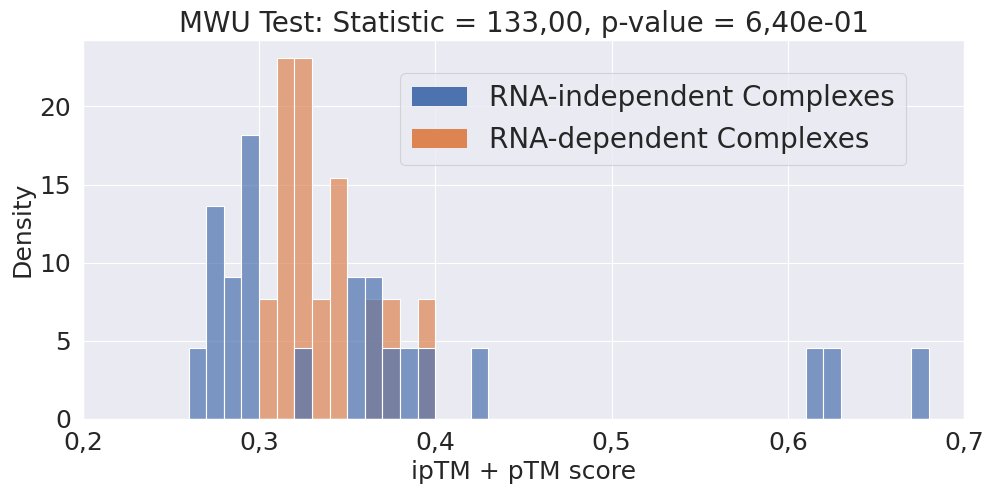

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
import numpy as np

sns.set_style("darkgrid")
sns.set_context("paper", font_scale=0.9)

palette = {
    'RNase-independent': sns.color_palette('deep')[0],
    'RNase-dependent': sns.color_palette('deep')[1]
}

plt.figure(figsize=(10, 5))

all_vals = df_average['ipTM+pTM'].dropna().values

bin_width = 0.01
min_edge = np.floor(all_vals.min() / bin_width) * bin_width
max_edge = np.ceil(all_vals.max() / bin_width) * bin_width
bins = np.arange(min_edge, max_edge + bin_width, bin_width)

sns.histplot(
    data=df_average,
    x='ipTM+pTM',
    hue='class',
    bins=bins,
    stat='density',
    common_norm=False,
    alpha=0.7,
    palette=palette
)



title = f"MWU Test: Statistic = {U_stat:.2f}, p-value = {p_value:.2e}"
title = title.replace(".", ",")

plt.title(title, fontsize=20)
plt.xlabel("ipTM + pTM score", fontsize=18)
plt.ylabel("Density", fontsize=18)

ticks = np.arange(
    np.floor(all_vals.min() / 0.1) * 0.1,
    np.ceil(all_vals.max() / 0.1) * 0.1 + 0.1,
    0.1
)

labels = [
    "0" if abs(x) < 1e-9 else f"{x:.1f}".replace(".", ",")
    for x in ticks
]

plt.xticks(ticks, labels, fontsize=18)
plt.yticks(fontsize=18)
plt.xlim(0.2, 0.7)

legend_handles = [
    Patch(
        facecolor=palette['RNase-independent'],
        edgecolor='none',
        label='RNA-independent Complexes'
    ),
    Patch(
        facecolor=palette['RNase-dependent'],
        edgecolor='none',
        label='RNA-dependent Complexes'
    )
]

plt.legend(
    handles=legend_handles,
    loc="upper right",
    bbox_to_anchor=(0.95, 0.95),
    frameon=True,
    fontsize=20
)

plt.tight_layout()
plt.savefig(
    "/mnt/storage/ana01/results/thesis_figures/RNA_ipTM_pTM_histogram.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## B) L1KD DATASET

In [59]:
# Add ipTM+pTM scores to dataframe; positive

def read_json_file(file_path):
    with open(file_path, 'r') as file:
        data = json.load(file)
    return data

folder_path = "/mnt/storage/ana01/results/all_models_FCpos_no_CLK2_original"
rows = []

for folder in os.listdir(folder_path):
    if folder == '.DS_Store':
        continue
    elif folder.endswith("_multimer"):
        ranking_file = os.path.join(f"{folder_path}/{folder}", "ranking_debug.json")
        if os.path.exists(ranking_file):
            json_data = read_json_file(ranking_file)
            model_scores = json_data['iptm+ptm']  # Dictionary of model scores
            
            # Add each model as a new row
            for model_name, score in model_scores.items():
                rows.append({'Target': folder, 'Model': model_name, 'ipTM+pTM': score})
        else:
            print(f"ranking_debug.json not found in {folder}")

# Create the DataFrame from the rows list
df_pos = pd.DataFrame(rows)

Extract per model scores

In [60]:
# Per-model ipTM+pTM scores to dataframe; negative 

def read_json_file(file_path):
    with open(file_path, 'r') as file:
        data = json.load(file)
    return data


folder_path = "/mnt/storage/ana01/results/afm_6_L1KD_FCneg_no__MACF1_ABCG2_original"
rows = []

for folder in os.listdir(folder_path):
    if folder == '.DS_Store':
        continue
    elif folder.endswith("_multimer"):
        ranking_file = os.path.join(f"{folder_path}/{folder}", "ranking_debug.json")
        if os.path.exists(ranking_file):
            json_data = read_json_file(ranking_file)
            model_scores = json_data['iptm+ptm']  
            
            # Add each model as a new row
            for model_name, score in model_scores.items():
                rows.append({'Target': folder, 'Model': model_name, 'ipTM+pTM': score})
        else:
            print(f"ranking_debug.json not found in {folder}")

# Create the DataFrame from the rows list
df = pd.DataFrame(rows)

In [ ]:
df_pos['class']='L1KD correlated'
df['class']='L1KD anti-correlated'

cols_to_keep = ['Target', 'ipTM+pTM', 'class']

df_combined = pd.concat(
    [df_pos[cols_to_keep], df[cols_to_keep]],
    ignore_index=True
)

,Target,ipTM+pTM,class
0,MRPS34_ORF2_multimer,0.326950,L1KD correlated
1,MRPS34_ORF2_multimer,0.300154,L1KD correlated
2,MRPS34_ORF2_multimer,0.279330,L1KD correlated
3,MRPS34_ORF2_multimer,0.316785,L1KD correlated
4,MRPS34_ORF2_multimer,0.297736,L1KD correlated


Average per complex

In [ ]:
df_average = (
    df_combined
    .groupby('Target', as_index=False)
    .agg({
        'ipTM+pTM': 'mean',
        'class': 'first'   
    })
)

df_average = df_average.sort_values(
    by='class', 
    ascending=False
)

,Target,ipTM+pTM,class
71,MAT2B_ORF2_multimer,0.293575,L1KD correlated
99,RBM8A_ORF2_multimer,0.396750,L1KD correlated
119,SRSF6_ORF2_multimer,0.363982,L1KD correlated
118,SRSF3_ORF2_multimer,0.383867,L1KD correlated
117,SRSF1_ORF2_multimer,0.297486,L1KD correlated


In [64]:
from scipy.stats import mannwhitneyu


pos_scores = df_average.loc[df_average['class'] == 'L1KD correlated', 'ipTM+pTM']
neg_scores = df_average.loc[df_average['class'] == 'L1KD anti-correlated', 'ipTM+pTM']

# MWU one-sided (pos > neg)
U_stat, p_value = mannwhitneyu(
    pos_scores,
    neg_scores,
    alternative='greater'
)


Histogram of score distriburions per complex (Figure A7)

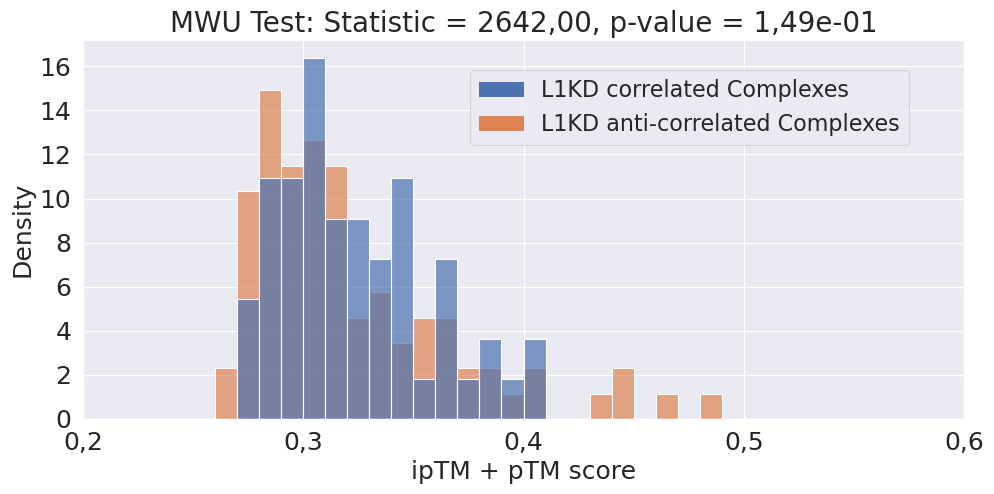

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
import numpy as np

sns.set_style("darkgrid")
sns.set_context("paper", font_scale=0.9)

palette = {
    'L1KD correlated': sns.color_palette('deep')[0],
    'L1KD anti-correlated': sns.color_palette('deep')[1]
}

plt.figure(figsize=(10, 5))

all_vals = df_average['ipTM+pTM'].dropna().values

bin_width = 0.01
min_edge = np.floor(all_vals.min() / bin_width) * bin_width
max_edge = np.ceil(all_vals.max() / bin_width) * bin_width
bins = np.arange(min_edge, max_edge + bin_width, bin_width)

sns.histplot(
    data=df_average,
    x='ipTM+pTM',
    hue='class',
    bins=bins,
    stat='density',
    common_norm=False,
    alpha=0.7,
    palette=palette
)


title = f"MWU Test: Statistic = {U_stat:.2f}, p-value = {p_value:.2e}"
title = title.replace(".", ",")

plt.title(title, fontsize=20)
plt.xlabel("ipTM + pTM score", fontsize=18)
plt.ylabel("Density", fontsize=18)

ticks = np.arange(0, 1.01, 0.1)
labels = [
    "0" if abs(x) < 1e-9 else f"{x:.1f}".replace(".", ",")
    for x in ticks
]

plt.xticks(ticks, labels, fontsize=18)
plt.yticks(fontsize=18)

legend_handles = [
    Patch(
        facecolor=palette['L1KD correlated'],
        edgecolor='none',
        label='L1KD correlated Complexes'
    ),
    Patch(
        facecolor=palette['L1KD anti-correlated'],
        edgecolor='none',
        label='L1KD anti-correlated Complexes'
    )
]

plt.legend(
    handles=legend_handles,
    loc="upper right",
    bbox_to_anchor=(0.95, 0.95),
    frameon=True,
    fontsize=16
)
plt.xlim(0.2, 0.6)
plt.tight_layout()
plt.savefig(
    "/mnt/storage/ana01/results/thesis_figures/L1KD_ipTM_pTM_histogram.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()